# Exemplo 1 - Probabilidade de precipitação anual

Os valores da precipitação anual em College Station, Texas, de 1911 a 1979 são mostrados na Tabela e plotados como uma série temporal na Figura. Qual é a probabilidade da precipitação anual R em qualquer ano seja inferior a 35 polegadas? Maior que 45 pol? Entre 35 e 45 polegadas?

**Precipitação anual na College Station, Texas, 1911-1979 (pol)**

| Year | 1910 | 1920 | 1930 | 1940 | 1950 | 1960 | 1970 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 0 |     | 48.7 | 44.8 | 49.3 | 31.2 | 46.0 | 33.9 |
| 1 | 39.9 | 44.1 | 34.0 | 44.2 | 27.0 | 44.3 | 31.7 |
| 2 | 31.0 | 42.8 | 45.6 | 41.7 | 37.0 | 37.8 | 31.5 |
| 3 | 42.3 | 48.4 | 37.3 | 30.8 | 46.8 | 29.6 | 59.6 |
| 4 | 42.1 | 34.2 | 43.7 | 53.6 | 26.9 | 35.1 | 50.5 |
| 5 | 41.1 | 32.4 | 41.8 | 34.5 | 25.4 | 49.7 | 38.6 |
| 6 | 28.7 | 46.4 | 41.1 | 50.3 | 23.0 | 36.6 | 43.4 |
| 7 | 16.8 | 38.9 | 31.2 | 43.8 | 56.5 | 32.5 | 28.7 |
| 8 | 34.1 | 37.3 | 35.2 | 21.6 | 43.4 | 61.7 | 32.0 |
| 9 | 56.4 | 50.6 | 35.1 | 47.1 | 41.3 | 47.4 | 51.8 |

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy

In [2]:
# Baixa dados da College Station, Texas
!gdown 122MCZkRoniGlkFXnLJLTvKJcLu-lbcZW

Downloading...
From: https://drive.google.com/uc?id=122MCZkRoniGlkFXnLJLTvKJcLu-lbcZW
To: /content/p_College_Station_Texas.csv
100% 700/700 [00:00<00:00, 3.11MB/s]


In [3]:
df  = pd.read_csv('p_College_Station_Texas.csv', index_col= 0, sep =',')
df.index=pd.to_datetime(df.index,format='%Y')
df

,p(in)
Year,
1911-01-01,39.9
1912-01-01,31.0
1913-01-01,42.3
1914-01-01,42.1
1915-01-01,41.1
...,...
1975-01-01,38.6
1976-01-01,43.4
1977-01-01,28.7


In [4]:
# Fazer uma cópia
df_pluv = df.copy()
df_pluv

,p(in)
Year,
1911-01-01,39.9
1912-01-01,31.0
1913-01-01,42.3
1914-01-01,42.1
1915-01-01,41.1
...,...
1975-01-01,38.6
1976-01-01,43.4
1977-01-01,28.7


## 1. Cálculo da precipitação anual

In [6]:
# Acumula dados anuais
df_prec_anual  = df_pluv.resample("YE").sum()
df_prec_anual

,p(in)
Year,
1911-12-31,39.9
1912-12-31,31.0
1913-12-31,42.3
1914-12-31,42.1
1915-12-31,41.1
...,...
1975-12-31,38.6
1976-12-31,43.4
1977-12-31,28.7


## 2. Gráfico da série temporal da precipitação anual

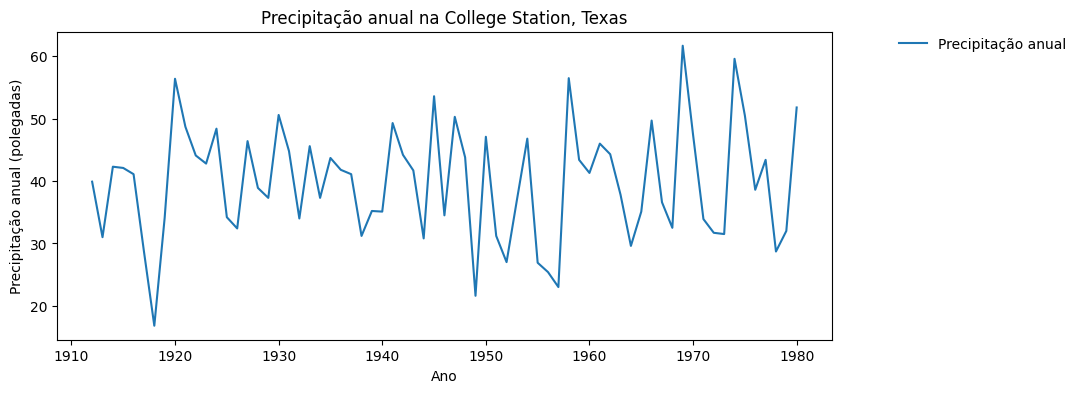

In [7]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(df_prec_anual['p(in)'], label='Precipitação anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação anual (polegadas)')
plt.title('Precipitação anual na College Station, Texas')
plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('precipitação_anual_CST.png', dpi = 300, bbox_inches='tight')
plt.show()

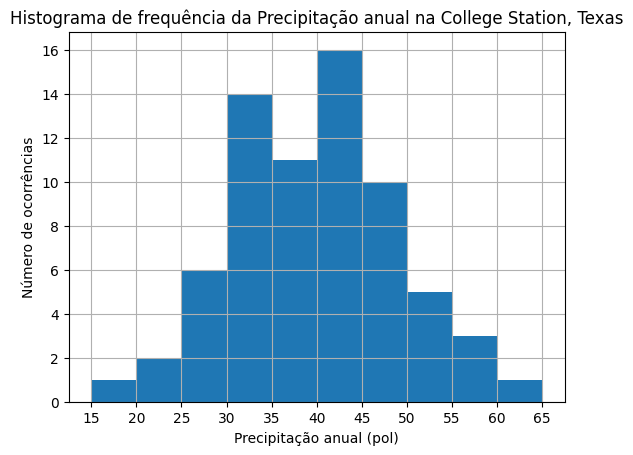

In [8]:
colunas = [15,20,25,30,35,40,45,50,55,60,65]
plt.xlabel('Precipitação anual (pol)')
plt.ylabel('Número de ocorrências')
plt.title('Histograma de frequência da Precipitação anual na College Station, Texas')
df_prec_anual['p(in)'].hist(bins=colunas)
plt.xticks(colunas)
plt.savefig('histograma_precipitação_anual.png', dpi = 300, bbox_inches='tight')
plt.show();

## 3. Qual é a probabilidade de que a precipitação anual R em qualquer ano seja:
* Inferior a 35 polegadas?
* Maior que 45 pol?
* Entre 35 e 45 pol?

**Definição de probabilidade**

Se uma amostra de $n$ observações tiver $n_a$ valores no intervalo do evento A, então a frequência relativa de A é $n_A/n$. À medida que o tamanho da amostra aumenta, a frequência relativa torna-se uma estimativa progressivamente melhor da probabilidade do evento, ou seja,
$$
P(A)=\lim _{n \rightarrow \infty} \frac{n_A}{n}
$$

Vamos aproximar a probabilidade de A pela sua frequências relativa:
$$
P(A) \approx \frac{n_A}{n}
$$


In [9]:
# O tamanho da minha amostra n é:
n = len(df_prec_anual['p(in)'])
print('Temos', n, 'anos de dados')

Temos 69 anos de dados


### Eventos

* $A$ é o evento $R < 35$ pol
* $B$ é o evento $R > 45$ pol
* $C$ é o evento $35 < R < 45$ pol

In [10]:
# Evento A
df_prec_anual['p(in)'][df_prec_anual['p(in)'] < 35]

,p(in)
Year,
1912-12-31,31.0
1916-12-31,28.7
1917-12-31,16.8
1918-12-31,34.1
1924-12-31,34.2
1925-12-31,32.4
1931-12-31,34.0
1937-12-31,31.2
1943-12-31,30.8


In [11]:
n_A = len(df_prec_anual['p(in)'][df_prec_anual['p(in)'] < 35])
n_A

23

In [12]:
# Evento B
df_prec_anual['p(in)'][df_prec_anual['p(in)'] > 45]

,p(in)
Year,
1919-12-31,56.4
1920-12-31,48.7
1923-12-31,48.4
1926-12-31,46.4
1929-12-31,50.6
1932-12-31,45.6
1940-12-31,49.3
1944-12-31,53.6
1946-12-31,50.3


In [13]:
n_B = len(df_prec_anual['p(in)'][df_prec_anual['p(in)'] > 45])
n_B

19

## Podemos aproximar a probabilidade de A e de B por


In [14]:
P_A = n_A/n
P_B = n_B/n
print('A probabilidade de R < 35 pol é', P_A)
print('A probabilidade de R > 45 pol é', P_B)

A probabilidade de R < 35 pol é 0.3333333333333333
A probabilidade de R > 45 pol é 0.2753623188405797


## A probabilidade de C é


In [15]:
P_C = 1 - P_A - P_B
print('A probabilidade de 35 < R < 45 pol é', P_C)

A probabilidade de 35 < R < 45 pol é 0.39130434782608703


#  Exemplo 11.1.2. Probabilidade consecutiva de precipitação anual

Supondo que a precipitação anual na College Station seja um processo independente.
* Calcule a probabilidade de que haverá dois anos sucessivos de precipitação inferior a 35 pol.
* Compare esta probabilidade estimada com a frequência relativa deste evento no conjunto de dados de 1911 a 1979.

### Evento

* Suponha que $D$ é o evento $R < 35$ pol para um ano qualquer
* Suponha que $E$ é o evento $R < 35$ pol para dois anos consecutivos

In [17]:
n_D = len(df_prec_anual['p(in)'][df_prec_anual['p(in)'] < 35])
P_D = n_D/n
print('A probabilidade de R < 35 pol é', P_D)

P_E = P_D**2
print('A probabilidade de R < 35 pol em dois anos consecutivos é', P_E)

A probabilidade de R < 35 pol é 0.3333333333333333
A probabilidade de R < 35 pol em dois anos consecutivos é 0.1111111111111111


In [18]:
df_prec_anual['35pol'] = 35
#df_prec_anual

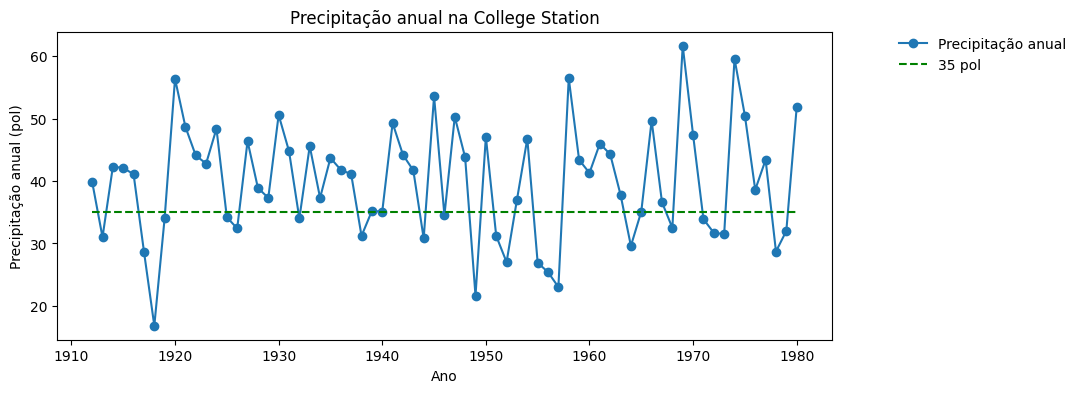

In [19]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(df_prec_anual['p(in)'], '-o', label='Precipitação anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação anual (pol)')
plt.title('Precipitação anual na College Station')
plt.plot(df_prec_anual['35pol'], color="green", label="35 pol", ls = "--")
plt.legend(bbox_to_anchor=(1.08, 1), loc='upper left', borderaxespad=0.,frameon=False)
plt.savefig('precipitação_anual_College_Station.png', dpi = 300, bbox_inches='tight')
plt.show()

In [20]:
contador = 0
for i in range(len(df_prec_anual)-1):
  if df_prec_anual['p(in)'][i] < 35 and df_prec_anual['p(in)'][i+1] < 35:
    contador +=1
contador

<ipython-input-20-2726641771>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if df_prec_anual['p(in)'][i] < 35 and df_prec_anual['p(in)'][i+1] < 35:


9

In [21]:
# Examinando o gráfico observa-se que a frequência relativa deste evento no conjunto de dados de 1981 a 2009 é
n_evento = 9 # existem dois pares de precipitação sequenciais abaixo da linha tracejada verde

P_evento = n_evento/(n-1)
print('A probabilidade de R < 35 pol em dois anos consecutivos é', P_evento)

A probabilidade de R < 35 pol em dois anos consecutivos é 0.1323529411764706


In [22]:
P_E, P_evento

(0.1111111111111111, 0.1323529411764706)

In [23]:
# print 2 decimal places
print('A probabilidade de R < 35 pol é {:.2f}'.format(P_A))
print('A probabilidade de R > 45 pol é {:.2f}'.format(P_B))
print('A probabilidade de 35 < R < 45 pol é {:.2f}'.format(P_C))
print('A probabilidade de R < 35 pol é {:.2f}'.format(P_D))
print('A probabilidade de R < 35 pol em dois anos consecutivos é {:.2f}'.format(P_E))
print('A probabilidade de R < 35 pol em dois anos consecutivos é {:.2f}'.format(P_evento))

A probabilidade de R < 35 pol é 0.33
A probabilidade de R > 45 pol é 0.28
A probabilidade de 35 < R < 45 pol é 0.39
A probabilidade de R < 35 pol é 0.33
A probabilidade de R < 35 pol em dois anos consecutivos é 0.11
A probabilidade de R < 35 pol em dois anos consecutivos é 0.13


As probabilidades estimadas a partir de dados amostrais, como nos Exemplos 1 e 2, são aproximadas, porque dependem dos valores específicos das observações numa amostra de tamanho limitado. Uma abordagem alternativa é ajustar uma função de distribuição de probabilidade aos dados e depois determinar as probabilidades de eventos a partir desta função de distribuição.